# 🌳 靜態綠意與基礎路網建構 (Static Greenery & Base Network)
**任務 0：環境設定、雲端掛載與目標設定 (Environment Setup & AOI)**

本階段的目標是建立穩定的資料處理環境，並完成雲端資料庫的介接：
1. **環境套件**：載入 `osmnx`, `geopandas`, `shapely`, `rasterstats` 與 STAC API 模組。
2. **雲端掛載**：掛載 Google Drive 以讀取存放於雲端的樹木 Shapefile 資料。
3. **目標設定 (AOI)**：系統鎖定為 **臺北市大安區 (Da'an District)**，建立支援全運具（行人、自行車、車輛）的綜合基礎路網。

註：缺乏校園管理之樹木資料，教育部有，可能可以再跟老師詢問是不是可以協助取得，也可以暫時設定成沒有(我之前私下寄信是說不公開)

In [2]:
# ==========================================
# [Task 0] Environment Setup, Drive Mount & AOI
# ──────────────────────────────────────────────────────────────────
!pip install -q osmnx geopandas rasterstats pystac-client planetary-computer stackstac xarray rioxarray folium

import os
import warnings
warnings.filterwarnings('ignore')

# 1. 載入核心套件
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point, LineString, Polygon, box
import numpy as np
import rasterio
from rasterstats import zonal_stats
from pystac_client import Client
import planetary_computer as pc

# --- Google Drive 掛載 ---
from google.colab import drive
print("⏳ 正在掛載 Google Drive...")
drive.mount('/content/drive')

# 設定輸出目錄
OUTPUT_DIR = '/content/drive/MyDrive/遙測與空間資訊之分析與應用_Final_Project/靜態綠意與基礎路網/Output_Data/'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ==========================================
# [補充] 解決 Matplotlib 中文顯示為方塊的問題
# ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

print("⏳ 正在下載並設定中文字體...")
# 從開源庫下載思源黑體 (Noto Sans TC)
!wget -q -O NotoSansTC.otf https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf

# 載入字體到 Matplotlib
fm.fontManager.addfont('NotoSansTC.otf')

# 設定全域字體與解決負號顯示問題
plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 中文字體設定完成！請重新執行剛剛的繪圖 Cell。")

# --- 變數與 AOI 設定 ---
# 💡 修正點：直接使用繁體中文，OSM 的 Nominatim 搜尋器對在地語言的辨識度最高！
PLACE_NAME = "大安區, 台北市, 台灣"
TREE_SHP_PATH = '/content/drive/MyDrive/遙測與空間資訊之分析與應用_Final_Project/GIS_data/大安區樹木/Trees_Daan.shp'
# 定義路網擷取排除清單：高架橋、快速道路、第一/第二級主幹道及其聯絡道
excluded_hwys = "motorway|motorway_link|trunk|trunk_link|primary|primary_link|secondary|secondary_link"

ox.settings.log_console = True
ox.settings.use_cache = True

print("-" * 50)
print(f"✅ 環境建置完成！")
print(f"📍 研究區域 (AOI): {PLACE_NAME}")
print(f"🌲 樹木資料路徑: {TREE_SHP_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 16.0 MB/s eta 0:00:00
⏳ 正在掛載 Google Drive...
Mounted at /content/drive
⏳ 正在下載並設定中文字體...
✅ 中文字體設定完成！請重新執行剛剛的繪圖 Cell。
--------------------------------------------------
✅ 環境建置完成！
📍 研究區域 (AOI): 大安區, 台北市, 台灣
🌲 樹木資料路徑: /content/drive/MyDrive/遙測與空間資訊之分析與應用_Final_Project/GIS_data/大安區樹木/Trees_Daan.shp


# 🗺️ [Task 1.1] 人行環境基礎路網萃取 (Pedestrian-Focused Network)

為了專注於「人行環境」的微氣候與安全性，我們調整了路網獲取策略。
**核心策略 (Custom Filter)：**
不使用粗糙的 `network_type='all'`，而是透過自訂過濾器 (`custom_filter`)，精準**剔除高快速道路與汽車主幹道** (`motorway`, `trunk`, `primary`, `secondary` 及其附屬聯絡道)。
如此一來，留下來的將會是生活巷弄 (`residential`)、服務道路 (`service`)、人行步道 (`footway`, `pedestrian`) 以及次要支線 (`tertiary`)，大幅提升後續行人路徑分析的合理性。

註：因實際plot發現大型道路周邊人行footway完整，可以代表行人、自行車通常會走的位置，所以剔除大型道路分析。後面路網分析再以這些選取的道路類型分析，不需要針對所有路網，因為是行人、自行車為主。

In [5]:
# ==========================================
# [Task 1.1] Fetch Pedestrian-Focused Network & CRS Check
# ──────────────────────────────────────────────────────────────────
import osmnx as ox
import geopandas as gpd

print(f"⏳ 正在從 OpenStreetMap 下載「{PLACE_NAME}」的人行環境路網...")
print("💡 策略調整：使用 custom_filter 剔除汽車主幹道，保留巷弄與次要道路...")

try:
    # 1. 建立自訂過濾器 (Overpass QL 語法)
    # 語法解釋：抓取有 highway 標籤的線段，且 highway 的值「不包含」上述類別
    custom_query = f'["highway"]["area"!~"yes"]["highway"!~"{excluded_hwys}"]'

    # 下載過濾後的路網 Graph
    G = ox.graph_from_place(PLACE_NAME, custom_filter=custom_query, retain_all=False)

    # 2. 將 Graph 轉換為 GeoDataFrames
    nodes, edges = ox.graph_to_gdfs(G)

    # 3. CRS 坐標系防呆檢驗
    if edges.crs is None:
        print("⚠️ 偵測到原始資料缺少 CRS，強制補入 EPSG:4326 (WGS84)")
        edges = edges.set_crs(epsg=4326)
        nodes = nodes.set_crs(epsg=4326)
    else:
        print(f"✅ 原始坐標系檢驗通過: {edges.crs}")

    print("-" * 50)
    print(f"✅ 人行環境路網萃取完成！")
    print(f"📊 大安區過濾後路網統計:")
    print(f"   > 節點 (Nodes): {len(nodes):,} 個")
    print(f"   > 路段 (Edges): {len(edges):,} 條 (數量應比之前少，更加輕量精準)")

    # 4. 預覽屬性
    keep_cols = ['highway', 'lanes', 'width', 'name', 'maxspeed', 'geometry']
    view_cols = [col for col in keep_cols if col in edges.columns]
    display(edges[view_cols].head(3))

except Exception as e:
    print("-" * 50)
    print(f"❌ 獲取路網失敗，錯誤訊息: {e}")

⏳ 正在從 OpenStreetMap 下載「大安區, 台北市, 台灣」的人行環境路網...
💡 策略調整：使用 custom_filter 剔除汽車主幹道，保留巷弄與次要道路...
✅ 原始坐標系檢驗通過: epsg:4326
--------------------------------------------------
✅ 人行環境路網萃取完成！
📊 大安區過濾後路網統計:
   > 節點 (Nodes): 9,785 個
   > 路段 (Edges): 25,332 條 (數量應比之前少，更加輕量精準)


highway lanes width  name maxspeed  \
u        v           key                                           
51413397 6657790527  0    residential   NaN   NaN  垂葉榕道      NaN   
         12252572486 0       tertiary     2  15.5  椰林大道      NaN   
         12234568157 0       tertiary     2  15.5  椰林大道      NaN   

                                                                   geometry  
u        v           key                                                     
51413397 6657790527  0    LINESTRING (121.5359 25.01728, 121.5359 25.01739)  
         12252572486 0    LINESTRING (121.5359 25.01728, 121.53548 25.01...  
         12234568157 0    LINESTRING (121.5359 25.01728, 121.53653 25.01...

# ✂️ [Task 1.2] 路寬屬性補全與路段幾何細分 (Densification)

1. **路寬補全 (Imputation)**：根據臺北市市區道路標準，推算 OSM 缺失的 `width` 屬性。
2. **座標投影 (Projection)**：將 WGS84 轉換為 TWD97 (`EPSG:3826`)，確保長度單位為公尺。
3. **幾何細分 (Densification)**：設定最大長度閾值 (`MAX_SEGMENT_LENGTH = 50m`)。利用 Shapely 將過長的路段切割成多個等長的短線段，以確保後續的 NDVI 綠意統計能真實反映局部的微氣候變化。

In [6]:
# ==========================================
# [Task 1.2] Attribute Imputation & Densification
# ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from shapely.geometry import LineString, MultiLineString
from shapely.ops import substring

print("⏳ [1/3] 正在執行路寬屬性補全 (Imputation)...")

width_map = {
    'primary': 30, 'secondary': 20, 'tertiary': 12,
    'residential': 8, 'living_street': 6, 'service': 4,
    'pedestrian': 3, 'footway': 2
}

def estimate_width(row):
    w = row.get('width')
    if isinstance(w, list): w = w[0]
    if pd.notna(w):
        try: return float(str(w).split(';')[0].replace('m', '').replace(' ', ''))
        except: pass
    h_type = row.get('highway')
    if isinstance(h_type, list): h_type = h_type[0]
    return width_map.get(h_type, 6)

edges['est_width'] = edges.apply(estimate_width, axis=1)

print("⏳ [2/3] 轉換至 TWD97 (EPSG:3826) 進行公尺級運算...")
# 轉為 TWD97 才能精確計算公尺長度
edges_twd97 = edges.to_crs(epsg=3826)

print("⏳ [3/3] 正在執行路段幾何細分 (Densification)...")
MAX_SEG_LENGTH = 50.0  # 設定最大路段長度為 50 公尺

# 定義線段切割函數
def split_line(line, max_len):
    if line.length <= max_len:
        return [line]

    # 計算需要切成幾段 (無條件進位)
    num_segments = int(np.ceil(line.length / max_len))
    seg_len = line.length / num_segments # 平均分配每段長度

    segments = []
    for i in range(num_segments):
        start_dist = i * seg_len
        end_dist = (i + 1) * seg_len
        # 利用 shapely.ops.substring 擷取線段
        segments.append(substring(line, start_dist, end_dist))
    return segments

# 建立新的 DataFrame 來存放切碎後的地圖
dense_rows = []

for idx, row in edges_twd97.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue

    # 處理可能出現的 MultiLineString (例如複雜圓環或交叉口)
    lines = list(geom.geoms) if isinstance(geom, MultiLineString) else [geom]

    for line in lines:
        segmented_lines = split_line(line, MAX_SEG_LENGTH)
        for seg_line in segmented_lines:
            new_row = row.copy()
            new_row['geometry'] = seg_line
            # 可以順便把這段的實際長度存起來
            new_row['seg_length'] = seg_line.length
            dense_rows.append(new_row)

# 重組為 GeoDataFrame，並繼承原本的 TWD97 坐標系
edges_dense = gpd.GeoDataFrame(dense_rows, crs=edges_twd97.crs)

# 重置 index，以防切割後出現重複的 index
edges_dense = edges_dense.reset_index(drop=True)

print("-" * 50)
print(f"✅ 路段細分完成！")
print(f"📊 幾何切割統計:")
print(f"   > 切割前原始路段數: {len(edges_twd97):,} 條")
print(f"   > 切割後 (每段<={MAX_SEG_LENGTH}m) 總段數: {len(edges_dense):,} 條")

⏳ [1/3] 正在執行路寬屬性補全 (Imputation)...
⏳ [2/3] 轉換至 TWD97 (EPSG:3826) 進行公尺級運算...
⏳ [3/3] 正在執行路段幾何細分 (Densification)...
--------------------------------------------------
✅ 路段細分完成！
📊 幾何切割統計:
   > 切割前原始路段數: 25,332 條
   > 切割後 (每段<=50.0m) 總段數: 31,872 條


# 🗺️ [Task 1.3] 細分路網動態緩衝區建立與全區視覺化

本階段將針對已完成「幾何細分 (Densification)」的路網 (`edges_dense`) 建立多邊形緩衝區。
1. **動態擴展**：套用 `半徑 = (路寬 / 2) + 3m` 的邏輯，為每一小段道路建立獨立的綠意偵測範圍。

    註：若超過3m會有顯然不能遮蔭到的樹木也被計入的問題，測試後取路寬再往外拓展3m


2. **全區渲染**：將大安區全區數萬筆的細分緩衝區投影回 WGS84，並疊加於國土測繪中心 (NLSC) 電子地圖上進行全面性檢核。

In [7]:
# ==========================================
# [Task 1.3] Dynamic Buffering on Dense Network & Full Visualization
# ──────────────────────────────────────────────────────────────────
import folium
import geopandas as gpd

print("⏳ [1/4] 正在為「細分後」的完整路網建立動態緩衝區...")
OFFSET = 3  # 側邊偏移量 (公尺)，用來捕捉路緣石外的行道樹

# 確保當前使用的是 EPSG:3826 (公尺單位)
edges_dense_twd97 = edges_dense.to_crs(epsg=3826)

# 💡 建立 Buffer 並直接更新幾何欄位
edges_dense_twd97['geometry'] = edges_dense_twd97.apply(
    lambda row: row.geometry.buffer((row['est_width'] / 2) + OFFSET), axis=1
)

print("⏳ [2/4] 座標系轉換回 WGS84 (EPSG:4326) 以供地圖渲染...")
edges_dense_viz = edges_dense_twd97.to_crs(epsg=4326)

print(f"⏳ [3/4] 準備渲染 {len(edges_dense_viz):,} 筆緩衝區資料...")
print("⚠️ 系統提示：繪製大安區全區數萬筆多邊形需要較長運算時間，且會消耗瀏覽器記憶體。請耐心等候...")

# 建立 Folium 地圖，中心點設於大安森林公園附近
m = folium.Map(location=[25.026, 121.543], zoom_start=14, control_scale=True)

# 介接國土測繪中心 (NLSC) WMTS
nlsc_url = "https://wmts.nlsc.gov.tw/wmts/EMAP/default/GoogleMapsCompatible/{z}/{y}/{x}"
folium.TileLayer(
    tiles=nlsc_url,
    attr="© 國土測繪中心 (NLSC)",
    name="國土測繪通用版電子地圖",
    overlay=False
).add_to(m)

# 加入完整的 GeoJson
# 💡 防呆機制：如果你的網頁直接卡死崩潰，請將下方的 `edges_dense_viz` 改為 `edges_dense_viz.sample(3000)` 來進行隨機抽樣檢視。
folium.GeoJson(
    edges_dense_viz,  # 這裡直接餵入完整資料！
    name="全區道路細分緩衝區 (Dense Buffers)",
    style_function=lambda x: {
        'fillColor': '#2ecc71',
        'color': '#27ae60',
        'weight': 0.5,  # 邊界線調細一點，避免全區看起來黑壓壓一片
        'fillOpacity': 0.4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'highway', 'est_width', 'seg_length'],
        aliases=['路名:', '道路等級:', '推算路寬(m):', '段落長度(m):']
    )
).add_to(m)

folium.LayerControl().add_to(m)
print("✅ [4/4] Task 1.3 執行成功！請縮放地圖檢視全區緩衝區覆蓋狀況。")

# 顯示地圖
m

Output hidden; open in https://colab.research.google.com to view.

# 🌲 [Task 2.1] 實體樹木空間交集與遮蔽量統計 (Vector Point Intersection)

本階段我們將進行「向量對向量」的空間交集運算：
1. **載入樹木圖資**：讀取存放在 Google Drive 的 `Trees_Daan.shp` 檔案。
2. **座標對齊 (CRS Alignment)**：確保樹木點位與路網緩衝區皆處於 `EPSG:3826 (TWD97)` 坐標系，以確保 100% 的幾何精確度。
3. **空間交集 (Spatial Join)**：利用 `geopandas.sjoin` 運算，判定每一棵樹屬於哪一個路段緩衝區。
4. **指標計算**：
    * **樹木數量 (Tree Count)**：該路段內的實體樹木總數。
    * **有效遮蔽當量 (Shading Equivalent)**：(進階任務) 若資料庫含有樹冠幅 (Crown) 或胸徑 (DBH)，我們將計算累加遮蔽面積；若無，則以預設權重計算。

In [8]:
# ==========================================
# [Task 2.1] Tree Data Loading & Spatial Intersection
# ──────────────────────────────────────────────────────────────────
import geopandas as gpd
import pandas as pd

print("⏳ [1/4] 正在載入大安區樹木 Shapefile...")
try:
    # 讀取 Google Drive 中的樹木資料
    trees = gpd.read_file(TREE_SHP_PATH)

    # 強制座標轉換至 TWD97 (與路網一致)
    if trees.crs != "EPSG:3826":
        trees = trees.to_crs(epsg=3826)

    print(f"✅ 成功載入 {len(trees):,} 棵樹木資料！")
except Exception as e:
    print(f"❌ 載入失敗，請確認路徑是否正確: {e}")

print("⏳ [2/4] 執行空間交集 (Spatial Join)...")
# 使用 edges_dense_twd97 (幾何為 Buffer 多邊形) 與 trees (點) 進行交集
# op='contains' 表示多邊形包含點
tree_join = gpd.sjoin(trees, edges_dense_twd97, predicate='within', how='inner')

print("⏳ [3/4] 正在統計各路段遮蔽指標...")
# 依據路段的唯一索引 (index) 進行分組統計
# 統計項目：1. 樹木數量 2. 假設每棵樹預設遮蔽面積為 15 平方公尺 (若無屬性則使用此值)
tree_stats = tree_join.groupby(tree_join.index_right).agg(
    tree_count=('geometry', 'count')
)

# 將統計結果合併回細分路網 edges_dense_twd97
# 先初始化為 0，再填充有資料的路段
edges_dense_twd97['tree_count'] = 0
edges_dense_twd97.update(tree_stats)

# 計算樹木密度 (每公尺有幾棵樹)
edges_dense_twd97['tree_density'] = edges_dense_twd97['tree_count'] / edges_dense_twd97['seg_length']

print("-" * 50)
print(f"✅ 空間統計完成！")
print(f"📊 統計摘要:")
print(f"   > 成功與路網關聯的樹木: {len(tree_join):,} 棵")
print(f"   > 擁有樹木的路段數: {len(tree_stats):,} 條")
print(f"   > 最高樹木密度: {edges_dense_twd97['tree_density'].max():.4f} 棵/米")

# 預覽統計結果
display(edges_dense_twd97[edges_dense_twd97['tree_count'] > 0][['name', 'tree_count', 'tree_density']].head())

⏳ [1/4] 正在載入大安區樹木 Shapefile...
✅ 成功載入 23,192 棵樹木資料！
⏳ [2/4] 執行空間交集 (Spatial Join)...
⏳ [3/4] 正在統計各路段遮蔽指標...
--------------------------------------------------
✅ 空間統計完成！
📊 統計摘要:
   > 成功與路網關聯的樹木: 32,122 棵
   > 擁有樹木的路段數: 7,682 條
   > 最高樹木密度: 1.9893 棵/米


,name,tree_count,tree_density
13,師大路,1,0.038413
14,師大路,1,0.032554
15,師大路,1,0.032554
16,師大路,2,0.052987
18,師大路,8,0.191280


# 🗺️ [Task 2.2] 樹木分佈與遮蔽強度視覺化

為了檢核統計結果，我們將產出雙層地圖：
1. **底層**：細分路網緩衝區，顏色深淺代表「樹木密度」。
2. **頂層**：原始樹木點位，用以比對點位與統計值是否對位。
這能直觀展現大安區哪些街道（如仁愛路、敦化南路）具備優質的靜態遮蔭。

In [9]:
# ==========================================
# [Task 2.2] Multi-Layer Control Map Visualization
# ──────────────────────────────────────────────────────────────────
import folium
import branca.colormap as cm

print("⏳ 正在生成多圖層互動地圖...")

# 1. 座標轉換供繪圖使用 (WGS84)
edges_tree_viz = edges_dense_twd97.to_crs(epsg=4326)

# 2. 建立樹木密度色階
tree_cmap = cm.LinearColormap(
    colors=['#f7fcf0', '#78c679', '#004529'],
    vmin=0, vmax=edges_tree_viz['tree_count'].quantile(0.95)
)

# 3. 初始化地圖：預設使用簡潔底圖
m_final = folium.Map(location=[25.026, 121.543], zoom_start=15, tiles="CartoDB positron")

# 4. [圖層 1]：國土測繪中心 (NLSC) 電子地圖 (預設不顯示)
nlsc_url = "https://wmts.nlsc.gov.tw/wmts/EMAP/default/GoogleMapsCompatible/{z}/{y}/{x}"
folium.TileLayer(
    tiles=nlsc_url,
    attr="© 國土測繪中心 (NLSC)",
    name="1. 國土測繪中心 (電子地圖)",
    overlay=True,
    show=False
).add_to(m_final)

# 5. [圖層 2]：路網遮蔽強度 (根據樹木數量分色)
folium.GeoJson(
    edges_tree_viz,
    name="2. 路段遮蔽強度 (Tree Count)",
    style_function=lambda x: {
        'fillColor': tree_cmap(x['properties']['tree_count']),
        'color': 'gray', 'weight': 0.1, 'fillOpacity': 0.6
    },
    tooltip=folium.GeoJsonTooltip(fields=['name', 'tree_count'], aliases=['路名:', '樹木數量:'])
).add_to(m_final)

# 6. [圖層 3]：原始樹木點位 (預設不顯示)
trees_layer = folium.FeatureGroup(name="3. 原始樹木點位 (Sample)", show=False)
trees_sample = trees.to_crs(epsg=4326).sample(min(1500, len(trees)))
for _, row in trees_sample.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=1.5, color='green', fill=True, opacity=0.4
    ).add_to(trees_layer)
trees_layer.add_to(m_final)

# 加上色階與控制面板
tree_cmap.add_to(m_final)
folium.LayerControl(collapsed=False).add_to(m_final)

print("✅ 地圖生成成功！請使用右上角選單切換底圖或樹木圖層。")
m_final

Output hidden; open in https://colab.research.google.com to view.

# 🛰️ [Task 2.3] 2025 夏季 NDVI 網格統計、影像品管與動態圖層檢視

本步驟執行 Sentinel-2 衛星影像的網格處理與統計：
1. **夏季影像檢索**：鎖定 **2025-06-01 至 2025-08-31**（夏季高溫植被生長峰值期）進行低雲量影像搜尋。
2. **影像品管 (QA Plot)**：
    * **儲存 ID**：儲存該影像 Product ID 為變數 `SELECTED_IMAGE_ID`，供未來參考。
    * **並列繪圖**：並列 Plot 出該影像的 **原始 RGB 對比** 與 **計算後的 NDVI 對比**。NDVI 色階範圍定為 -1 到 1，綠色越深代表綠意越強，幫助我們確認影像質量。
3. **分區統計 (Zonal Stats)**：
    * **座標對齊**：確保網格（EPSG:3826）與向量路網緩衝區（EPSG:3826）座標完全對齊。
    * **均值計算**：計算各路段 50m 緩衝區內的網格像素平均值（Mean NDVI），寫入屬性欄位 `ndvi_mean`。
4. **夏季綠意動態地圖**：生成一個 Folium 地圖，以色階展示各路段被 **Assign** 進去的 NDVI 均值，並具備底圖（国土地圖）開關功能。

In [10]:
# ==========================================
# [Task 2.3] Sentinel-2 Summer NDVI Stats & Multi-Layer Map (Reflectance Corrected)
# ──────────────────────────────────────────────────────────────────
import stackstac
import xarray as xr
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
from pystac_client import Client
import planetary_computer as pc
import folium
import branca.colormap as cm
import numpy as np

print("⏳ [1/5] 正在搜尋 2025 夏季衛星影像...")

try:
    catalog.get_collections()
except (NameError, Exception):
    catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace)

bbox = tuple(edges_dense_twd97.to_crs(epsg=4326).total_bounds)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2025-06-01/2025-08-31",
    query={"eo:cloud_cover": {"lt": 15}}
)
items = list(search.get_items())

if not items:
    raise ValueError("❌ 找不到低雲量影像，請調整日期或雲量門檻。")

SELECTED_IMAGE_ID = items[0].id
print(f"✅ 成功找到低雲影像，Product ID: {SELECTED_IMAGE_ID}")

# ---------------------------------------------------------
# 💡 核心修正區：真實反射率轉換 (True Reflectance Conversion)
# ---------------------------------------------------------
print("⏳ [2/5] 正在進行光學反射率校正與 Plotting...")
data_wgs84 = stackstac.stack(items[0], assets=["B02", "B03", "B04", "B08"], bounds_latlon=bbox, epsg=4326)
data_wgs84 = data_wgs84.astype("float32")

# 扣除 ESA 的 1000 offset 並轉換為 0~1 的真實反射率
reflectance_wgs84 = ((data_wgs84 - 1000) / 10000).clip(0, 1)

# 計算 RGB 供視覺確認 (稍微放大 2.5 倍亮度以提升視覺對比)
rgb = reflectance_wgs84.sel(band=["B04", "B03", "B02"]).mean(dim="time").squeeze() * 2.5
# 使用真實反射率計算 NDVI
ndvi_wgs84 = (reflectance_wgs84.sel(band="B08") - reflectance_wgs84.sel(band="B04")) / (reflectance_wgs84.sel(band="B08") + reflectance_wgs84.sel(band="B04"))
ndvi_wgs84_img = ndvi_wgs84.mean(dim="time").squeeze().values

# 並列 Plot (Raw vs NDVI)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(np.moveaxis(rgb.values, 0, -1).clip(0, 1))
axes[0].set_title(f"1. 原始影像 (真實反射率 RGB)\nID: {SELECTED_IMAGE_ID[:30]}...")
axes[0].axis("off")

# 💡 色階修正：將範圍調整為 -0.2 到 0.8，還原高對比視覺
ndvi_plot = axes[1].imshow(ndvi_wgs84_img, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[1].set_title(f"2. 校正後的夏季 NDVI (品管圖)")
axes[1].axis("off")
fig.colorbar(ndvi_plot, ax=axes[1], label='NDVI 指數')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
print("⏳ [3/5] 正在載入 TWD97 網格並執行路段分區統計...")
data_twd97 = stackstac.stack(items[0], assets=["B04", "B08"], bounds_latlon=bbox, epsg=3826)
data_twd97 = data_twd97.astype("float32")

# 同樣執行反射率校正
reflectance_twd97 = ((data_twd97 - 1000) / 10000).clip(0, 1)
ndvi_twd97 = (reflectance_twd97.sel(band="B08") - reflectance_twd97.sel(band="B04")) / (reflectance_twd97.sel(band="B08") + reflectance_twd97.sel(band="B04"))
ndvi_twd97_img = ndvi_twd97.mean(dim="time").squeeze().values
transform = data_twd97.spec.transform

# 執行分區統計 (Zonal Stats)
res = zonal_stats(edges_dense_twd97, ndvi_twd97_img, affine=transform, stats="mean", nodata=np.nan)
edges_dense_twd97['ndvi_mean'] = [r['mean'] if r['mean'] is not None else 0 for r in res]

# ---------------------------------------------------------
print("⏳ [4/5] 正在生成夏季綠意互動地圖...")
edges_ndvi_viz = edges_dense_twd97.to_crs(epsg=4326)

# 💡 地圖色階同樣修正為 0 到 0.8 區間
ndvi_cmap = cm.LinearColormap(
    colors=['#d73027', '#fdae61', '#a6d96a', '#1a9641'], # 對應 RdYlGn
    vmin=0.0, vmax=0.8
)

m_ndvi = folium.Map(location=[25.026, 121.543], zoom_start=15, tiles="CartoDB positron")

nlsc_url = "https://wmts.nlsc.gov.tw/wmts/EMAP/default/GoogleMapsCompatible/{z}/{y}/{x}"
folium.TileLayer(
    tiles=nlsc_url, attr="© 國土測繪中心 (NLSC)", name="1. 國土測繪中心", overlay=True, show=True
).add_to(m_ndvi)

folium.GeoJson(
    edges_ndvi_viz,
    name="2. 路段夏季綠意 (NDVI 均值)",
    style_function=lambda x: {
        'fillColor': ndvi_cmap(x['properties']['ndvi_mean']),
        'color': 'gray', 'weight': 0.1, 'fillOpacity': 0.8
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'highway', 'ndvi_mean'],
        aliases=['路名:', '等級:', '夏季NDVI均值:']
    )
).add_to(m_ndvi)

ndvi_cmap.add_to(m_ndvi)
folium.LayerControl(collapsed=False).add_to(m_ndvi)

print("-" * 50)
print(f"✅ [5/5] Task 2.3 執行完成！全區夏季 NDVI 均值: {edges_dense_twd97['ndvi_mean'].mean():.4f}")
m_ndvi

Output hidden; open in https://colab.research.google.com to view.

# ⚖️ [Task 3] 靜態權重資料庫封裝與輸出 (Weight Integration & Export)

本階段將執行數據的最後一哩路：
1. **數值正規化 (Normalization)**：由於 NDVI (0~ 0.8) 與樹木密度 (0~ 0.2 棵/米) 的量綱不同，必須將其統一縮放至 `0.0 - 1.0` 區間。
2. **權重調和 (Weighted Scoring)**：計算最終的「路段遮蔭指數 (Shading Index)」。
   * **公式建議**：`Score = (NDVI_norm * 0.6) + (Tree_Density_norm * 0.4)`。
   * NDVI 代理整體的「平面植被分布」，而樹木密度代理「實體遮蔽點」。
3. **安全屬性注入**：根據 `highway` 類型賦予基礎安全分（例如：`pedestrian` 類型分數較高）。
4. **格式輸出**：
   * **GeoJSON**：供前端地圖渲染使用。
   * **GraphML**：保留拓樸關係，供 `NetworkX` 直接載入進行路徑演算法計算。

In [11]:
# ==========================================
# [Task 3.1] Normalization & Weight Integration (獨立維度版)
# ──────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

print("⏳ [1/3] 正在執行數據正規化 (Normalization)...")

# 1. 提取需要正規化的欄位
scaler = MinMaxScaler(feature_range=(0, 1))
cols_to_norm = ['ndvi_mean', 'tree_density']

# 針對這些指標進行 0-1 縮放
edges_dense_twd97[['ndvi_norm', 'tree_density_norm']] = scaler.fit_transform(
    edges_dense_twd97[cols_to_norm].fillna(0)
)

print("⏳ [2/3] 正在計算核心「遮蔭指數」...")

# 2. 定義計算公式 (專注於綠意與遮蔽)
# 權重設定：夏季 NDVI (60%) + 實體樹木密度 (40%)
W_NDVI = 0.6
W_TREES = 0.4

edges_dense_twd97['shading_index'] = (
    (edges_dense_twd97['ndvi_norm'] * W_NDVI) +
    (edges_dense_twd97['tree_density_norm'] * W_TREES)
)

print("⏳ [3/3] 正在注入獨立的「安全係數」屬性...")

# 3. 注入行人安全性基礎分 (Safety Score) 作為獨立欄位
safety_map = {
    'pedestrian': 1.0, 'footway': 1.0, 'steps': 1.0, 'cycleway': 0.9, 'living_street': 0.9,
    'path': 0.8, 'residential': 0.7, 'tertiary': 0.5, 'service': 0.4
}
edges_dense_twd97['safety_score'] = edges_dense_twd97['highway'].apply(
    lambda x: safety_map.get(x[0] if isinstance(x, list) else x, 0.3)
)

print("-" * 50)
print(f"✅ 雙維度指標整合完成！")
print(f"📊 大安區路網最終權重摘要:")
print(f"   > 平均遮蔭指數 (Shading Index): {edges_dense_twd97['shading_index'].mean():.4f}")
print(f"   > 平均安全係數 (Safety Score): {edges_dense_twd97['safety_score'].mean():.4f}")

# 預覽獨立的兩個評估維度
display(edges_dense_twd97[['name', 'highway', 'shading_index', 'safety_score']].head())

⏳ [1/3] 正在執行數據正規化 (Normalization)...
⏳ [2/3] 正在計算核心「遮蔭指數」...
⏳ [3/3] 正在注入獨立的「安全係數」屬性...
--------------------------------------------------
✅ 雙維度指標整合完成！
📊 大安區路網最終權重摘要:
   > 平均遮蔭指數 (Shading Index): 0.2506
   > 平均安全係數 (Safety Score): 0.7736


,name,highway,shading_index,safety_score
0,垂葉榕道,residential,0.365129,0.7
1,椰林大道,tertiary,0.300217,0.5
2,椰林大道,tertiary,0.303427,0.5
3,椰林大道,tertiary,0.331710,0.5
4,垂葉榕道,footway,0.232898,1.0


In [24]:
# ==========================================
# [Task 3.2] Final Export (Multi-Layer GPKG Delivery) - 拓樸防呆修正版
# ──────────────────────────────────────────────────────────────────
import os
import geopandas as gpd

print(f"⏳ 正在準備「邊與節點」三位一體資料包匯出至: {OUTPUT_DIR}...")

# 1. 建立匯出專用的 Edges 備份 (轉回 WGS84)
edges_final_wgs84 = edges_dense_twd97.to_crs(epsg=4326).copy()

# 💡 核心修正：檢查並提取拓樸索引 (u, v, key)
# OSMnx 分段後的物件，u, v, key 通常存在 MultiIndex 中。
if 'u' not in edges_final_wgs84.columns:
    edges_final_wgs84 = edges_final_wgs84.reset_index()

# 如果路網切分過程導致 key 遺失，我們補上預設值 0 確保格式完整
if 'key' not in edges_final_wgs84.columns:
    edges_final_wgs84['key'] = 0

# 2. 建立匯出專用的 Nodes 備份 (轉回 WGS84)
nodes_final_wgs84 = nodes.to_crs(epsg=4326).copy()

# 若 Nodes 的 osmid 被鎖在 index 中，也將其釋放出來
if 'osmid' not in nodes_final_wgs84.columns:
    nodes_final_wgs84 = nodes_final_wgs84.reset_index()

# 3. 屬性資料型別清理函數 (確保所有物件皆轉為字串，防止 GPKG/GeoJSON 格式衝突)
def clean_attributes(gdf):
    for col in gdf.columns:
        if col == 'geometry': continue
        # 如果是 list, dict 或物件型別，一律轉為字串
        if gdf[col].dtype == 'object' or gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
            gdf[col] = gdf[col].astype(str)
    return gdf

print("⏳ 正在清理 Edges 與 Nodes 屬性以確保相容性...")
edges_final_wgs84 = clean_attributes(edges_final_wgs84)
nodes_final_wgs84 = clean_attributes(nodes_final_wgs84)

# 4. 匯出格式一：GeoJSON (僅路段，供地圖前端使用)
geojson_file = os.path.join(OUTPUT_DIR, 'Daan_Shaded_Network(分段)_v1.geojson')
edges_final_wgs84.to_file(geojson_file, driver='GeoJSON')

# 5. 匯出格式二：GeoPackage (關鍵！同時包含 Edges 與 Nodes 圖層)
gpkg_file = os.path.join(OUTPUT_DIR, 'Daan_Shaded_Network(分段)_v1.gpkg')
# 分別存入不同的 layer 名稱
edges_final_wgs84.to_file(gpkg_file, layer='edges', driver="GPKG")
nodes_final_wgs84.to_file(gpkg_file, layer='nodes', driver="GPKG")

# 6. 匯出格式三：CSV (供演算法組快速讀取權重，不含幾何)
csv_file = os.path.join(OUTPUT_DIR, 'Daan_Shaded_Network(分段)_v1.csv')
# 💡 確保 u, v, key 被匯出，方便純文字層級的拓樸重建
edges_final_wgs84.drop(columns=['geometry']).to_csv(csv_file, index=False)

print("-" * 50)
print(f"🎉 跨小組對接資料包已就緒！(拓樸完整版)")
print(f"📦 已成功產出以下檔案：")
print(f"   1. {os.path.basename(geojson_file)} (GeoJSON - 僅 Edges)")
print(f"   2. {os.path.basename(gpkg_file)} (GPKG - 包含 'edges' 與 'nodes' 圖層)")
print(f"   3. {os.path.basename(csv_file)} (CSV - 純 Edges 屬性)")

⏳ 正在準備「邊與節點」三位一體資料包匯出至: /content/drive/MyDrive/遙測與空間資訊之分析與應用_Final_Project/靜態綠意與基礎路網/Output_Data/...
⏳ 正在清理 Edges 與 Nodes 屬性以確保相容性...
--------------------------------------------------
🎉 跨小組對接資料包已就緒！(拓樸完整版)
📦 已成功產出以下檔案：
   1. Daan_Shaded_Network(分段)_v1.geojson (GeoJSON - 僅 Edges)
   2. Daan_Shaded_Network(分段)_v1.gpkg (GPKG - 包含 'edges' 與 'nodes' 圖層)
   3. Daan_Shaded_Network(分段)_v1.csv (CSV - 純 Edges 屬性)


# 🔄 [Task 3.3] 原始路網拓樸還原與資料聚合 (Topology Restoration)

本步驟專為「路網導航演算法」設計：
1. **聚合運算 (Aggregation)**：以原始的 `osmid` 為基準，將 50m 細分路段的屬性聚合。
   * `shading_index` 與 `safety_score` 取**平均值 (Mean)**。
   * `tree_count` 取**加總值 (Sum)**。
2. **拓樸對齊 (Topology Alignment)**：將算出的聚合分數，合併回 Task 1.1 中最原始、只在實體十字路口才打斷的 `edges` GeoDataFrame。
3. **雙軌產出**：額外匯出 `Restored` 版本的 CSV 與 GeoJSON，供演算法組直接無縫套用 `NetworkX` 進行圖論計算。

# 🛠️ Task 3.3 拓樸還原邏輯修正說明 (Bug Fix Report)

## 1. 發現問題 (Issue Detected)
在執行 `GPKG` 轉換為 `GraphML` 的過程中，遭遇了 `ValidationError: gdf_edges must be multi-indexed by (u, v, key)`。
經查證，這是因為在 Task 3.3 的 `merge`（合併）過程中，Pandas 會自動丟棄原始 GeoDataFrame 的索引（Index）。在 OSMnx 的結構中，`u`, `v`, `key` 通常儲存在索引中，一旦丟失，路網的拓樸連結就會斷裂。

## 2. 修正邏輯 (The Fix)
為了確保輸出資料的「演算法相容性」，我們在聚合與匯出流程中加入了以下核心修正：

### A. 索引提取 (Index Recovery)
在進行任何屬性合併或幾何還原之前，強制執行 `.reset_index()`。
* **目的**：將隱藏在索引中的 `u`, `v`, `key` 欄位轉化為實體欄位（Columns），保證它們能參與後續的 `merge` 運算並被寫入硬體檔案。

### B. 欄位保全 (Column Retention)
在最後產出的 `edges` 圖層中，明確指定必須包含 `u`, `v`, `key` 欄位。
* **實務效益**：即使在 CSV 這種純文字格式中，路徑分析組也能透過這三個欄位重建 NetworkX 圖形，而不必重新計算空間對位。

## 3. 交接注意事項 (Handoff Notes)
* **GPKG 讀取**：後續同學讀取 `Daan_Shaded_Network(還原)_v1.gpkg` 時，請務必同時讀取 `edges` 與 `nodes` 兩個圖層。
* **索引重設**：使用 `osmnx.graph_from_gdfs()` 建立圖形前，請確保先執行 `edges.set_index(['u', 'v', 'key'])`。

In [13]:
# ==========================================
# [Task 3.3] Network Aggregation (Restore to OSM Topology)
# ──────────────────────────────────────────────────────────────────
import folium
import branca.colormap as cm
import numpy as np
import os
import geopandas as gpd

print("⏳ [1/3] 正在將細分路段的權重，聚合回原始 OSM 路網...")

# 1. 使用原始的 osmid 作為聚合鍵 (處理 list 轉 string 的狀況避免報錯)
edges_dense_twd97['osmid_str'] = edges_dense_twd97['osmid'].astype(str)

# 2. 定義聚合邏輯
agg_funcs = {
    'shading_index': 'mean',  # 指數類取平均
    'safety_score': 'mean',
    'tree_count': 'sum',      # 實體數量取加總
    'seg_length': 'sum'
}
grouped_stats = edges_dense_twd97.groupby('osmid_str').agg(agg_funcs).reset_index()

print("⏳ [2/3] 正在合併回原始路網並進行封裝...")
# 3. 拿出 Task 1.1 最原始、未切碎的路網 (edges)，確保為 WGS84 坐標系
edges_original = edges.copy()
if edges_original.crs != "EPSG:4326":
    edges_original = edges_original.to_crs(epsg=4326)

edges_original['osmid_str'] = edges_original['osmid'].astype(str)

# 4. 將統計結果合併回原始幾何 (Left Join)
edges_restored = edges_original.merge(grouped_stats, on='osmid_str', how='left')

# 填補空值 (極少數異常短的線段可能在細分時被捨棄)
edges_restored['shading_index'] = edges_restored['shading_index'].fillna(0)
edges_restored['safety_score'] = edges_restored['safety_score'].fillna(0.3)
edges_restored['tree_count'] = edges_restored['tree_count'].fillna(0)

# 5. 匯出還原版資料 (統一主檔名)
BASE_NAME = 'Daan_Shaded_Network(還原)_v1'
RESTORED_CSV = os.path.join(OUTPUT_DIR, f'{BASE_NAME}.csv')
RESTORED_GEOJSON = os.path.join(OUTPUT_DIR, f'{BASE_NAME}.geojson')
RESTORED_GPKG = os.path.join(OUTPUT_DIR, f'{BASE_NAME}.gpkg')

# 匯出 CSV (給演算法)
export_cols = ['osmid', 'name', 'highway', 'length', 'shading_index', 'safety_score', 'tree_count']
valid_cols = [c for c in export_cols if c in edges_restored.columns]
edges_restored[valid_cols].to_csv(RESTORED_CSV, index=False)

# 💡 新增：準備 Nodes 資料 (確保來自 Task 1.1 的 nodes 變數存在，並轉為 WGS84)
nodes_export = nodes.copy()
if nodes_export.crs != "EPSG:4326":
    nodes_export = nodes_export.to_crs(epsg=4326)

# 屬性清理函數：將 List/Dict 等複雜格式轉為字串，防止 GeoJSON 與 GPKG 報錯
def clean_attributes(gdf):
    for col in gdf.columns:
        if col == 'geometry': continue
        if gdf[col].dtype == 'object' or gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
            gdf[col] = gdf[col].astype(str)
    return gdf

edges_restored = clean_attributes(edges_restored)
nodes_export = clean_attributes(nodes_export)

# 匯出 GeoJSON (視覺化通常只需要 Edges)
edges_restored.to_file(RESTORED_GEOJSON, driver='GeoJSON')

# 💡 新增：寫入 GPKG，將 edges 與 nodes 分別存入不同圖層 (Layer)
edges_restored.to_file(RESTORED_GPKG, layer='edges', driver='GPKG')
nodes_export.to_file(RESTORED_GPKG, layer='nodes', driver='GPKG')


print("⏳ [3/3] 正在生成聚合後的原貌路網地圖...")
# 6. 生成互動地圖來確認聚合結果
m_restored = folium.Map(location=[25.026, 121.543], zoom_start=15, tiles="CartoDB positron")

# 建立色階
cmap_restore = cm.LinearColormap(
    colors=['#d73027', '#fdae61', '#a6d96a', '#1a9641'],
    vmin=0.0, vmax=0.8
)

folium.GeoJson(
    edges_restored,
    name="還原版 OSM 路網 (聚合遮蔭指數)",
    style_function=lambda x: {
        'color': cmap_restore(float(x['properties']['shading_index'])),
        'weight': 4 if float(x['properties']['shading_index']) > 0.4 else 2,
        'opacity': 0.8
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'highway', 'shading_index', 'tree_count'],
        aliases=['路名:', '道路等級:', '平均遮蔭分數:', '路段總樹木量(棵):']
    )
).add_to(m_restored)

cmap_restore.add_to(m_restored)
folium.LayerControl().add_to(m_restored)

print("-" * 50)
print(f"✅ 還原成功！已產出專供演算法使用的乾淨拓樸資料。")
print(f"📦 CSV: {os.path.basename(RESTORED_CSV)}")
print(f"📦 GeoJSON: {os.path.basename(RESTORED_GEOJSON)}")
print(f"📦 GeoPackage: {os.path.basename(RESTORED_GPKG)} (包含 edges 與 nodes 雙圖層)")
m_restored

Output hidden; open in https://colab.research.google.com to view.

In [23]:
# ==========================================
# [Task 3.3] Network Aggregation (Restore to OSM Topology) - 修正 u,v 遺失問題
# ──────────────────────────────────────────────────────────────────
import folium
import branca.colormap as cm
import numpy as np
import os
import geopandas as gpd

print("⏳ [1/3] 正在將細分路段的權重，聚合回原始 OSM 路網...")

edges_dense_twd97['osmid_str'] = edges_dense_twd97['osmid'].astype(str)

agg_funcs = {
    'shading_index': 'mean',
    'safety_score': 'mean',
    'tree_count': 'sum',
    'seg_length': 'sum'
}
grouped_stats = edges_dense_twd97.groupby('osmid_str').agg(agg_funcs).reset_index()

print("⏳ [2/3] 正在合併回原始路網並進行封裝...")
edges_original = edges.copy()
if edges_original.crs != "EPSG:4326":
    edges_original = edges_original.to_crs(epsg=4326)

# 💡 關鍵修復：在 merge 之前，把隱藏在 Index 的 u, v, key 變回實體欄位！
if 'u' not in edges_original.columns:
    edges_original = edges_original.reset_index()

edges_original['osmid_str'] = edges_original['osmid'].astype(str)

# 現在 merge 就不會弄丟 u, v, key 了
edges_restored = edges_original.merge(grouped_stats, on='osmid_str', how='left')

edges_restored['shading_index'] = edges_restored['shading_index'].fillna(0)
edges_restored['safety_score'] = edges_restored['safety_score'].fillna(0.3)
edges_restored['tree_count'] = edges_restored['tree_count'].fillna(0)

BASE_NAME = 'Daan_Shaded_Network(還原)_v1'
RESTORED_CSV = os.path.join(OUTPUT_DIR, f'{BASE_NAME}.csv')
RESTORED_GEOJSON = os.path.join(OUTPUT_DIR, f'{BASE_NAME}.geojson')
RESTORED_GPKG = os.path.join(OUTPUT_DIR, f'{BASE_NAME}.gpkg')

# 匯出 CSV 時，確保 u, v 被納入，這樣演算法組就能知道節點關係！
export_cols = ['u', 'v', 'key', 'osmid', 'name', 'highway', 'length', 'shading_index', 'safety_score', 'tree_count']
valid_cols = [c for c in export_cols if c in edges_restored.columns]
edges_restored[valid_cols].to_csv(RESTORED_CSV, index=False)

nodes_export = nodes.copy()
if nodes_export.crs != "EPSG:4326":
    nodes_export = nodes_export.to_crs(epsg=4326)

def clean_attributes(gdf):
    for col in gdf.columns:
        if col == 'geometry': continue
        if gdf[col].dtype == 'object' or gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
            gdf[col] = gdf[col].astype(str)
    return gdf

edges_restored = clean_attributes(edges_restored)
nodes_export = clean_attributes(nodes_export)

edges_restored.to_file(RESTORED_GEOJSON, driver='GeoJSON')
edges_restored.to_file(RESTORED_GPKG, layer='edges', driver='GPKG')
nodes_export.to_file(RESTORED_GPKG, layer='nodes', driver='GPKG')

print("⏳ [3/3] 正在生成聚合後的原貌路網地圖...")
# 6. 生成互動地圖來確認聚合結果
m_restored = folium.Map(location=[25.026, 121.543], zoom_start=15, tiles="CartoDB positron")

# 建立色階
cmap_restore = cm.LinearColormap(
    colors=['#d73027', '#fdae61', '#a6d96a', '#1a9641'],
    vmin=0.0, vmax=0.8
)

folium.GeoJson(
    edges_restored,
    name="還原版 OSM 路網 (聚合遮蔭指數)",
    style_function=lambda x: {
        'color': cmap_restore(float(x['properties']['shading_index'])),
        'weight': 4 if float(x['properties']['shading_index']) > 0.4 else 2,
        'opacity': 0.8
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'highway', 'shading_index', 'tree_count'],
        aliases=['路名:', '道路等級:', '平均遮蔭分數:', '路段總樹木量(棵):']
    )
).add_to(m_restored)

cmap_restore.add_to(m_restored)
folium.LayerControl().add_to(m_restored)

print("-" * 50)
print(f"✅ 還原成功！已產出專供演算法使用的乾淨拓樸資料。")
print(f"📦 CSV: {os.path.basename(RESTORED_CSV)}")
print(f"📦 GeoJSON: {os.path.basename(RESTORED_GEOJSON)}")
print(f"📦 GeoPackage: {os.path.basename(RESTORED_GPKG)} (包含 edges 與 nodes 雙圖層)")
print("✅ [3.3 執行完畢] GPKG 封裝完成，已成功保留拓樸資訊 (u, v)。")
m_restored

Output hidden; open in https://colab.research.google.com to view.

# 🧪 [Task 4] 數據交接模擬與完整性檢視 (Handoff Simulation)

本步驟模擬後續接手同學的作業流程，驗證產出檔案的可用性：
1. **讀取測試**：模擬從 Google Drive 重新載入 `Daan_Shaded_Network(還原)_v1.geojson`。
2. **屬性健診**：檢查 `shading_index` 與 `safety_score` 是否正確存在，且數值範圍落在 0.0 - 1.0。
3. **快速渲染測試**：使用 `Geopandas` 內建的繪圖功能，確認「不依賴複雜套件」的情況下也能看見路網圖形。
4. **拓樸驗證**：確認 CSV 中的 `osmid` 是否能與路網圖正確對接。

⏳ [1/3] 正在模擬隊友載入 GeoJSON 檔案...
✅ GeoJSON 載入成功！包含 25147 條完整路段幾何。
⏳ [2/3] 正在進行指標範圍檢查...
📊 遮蔭指數範圍: 0.01 ~ 0.71 (預期應在 0~1 之間)
🟢 [PASS] 權重正規化邏輯正確。
⏳ [3/3] 正在執行幾何渲染測試...


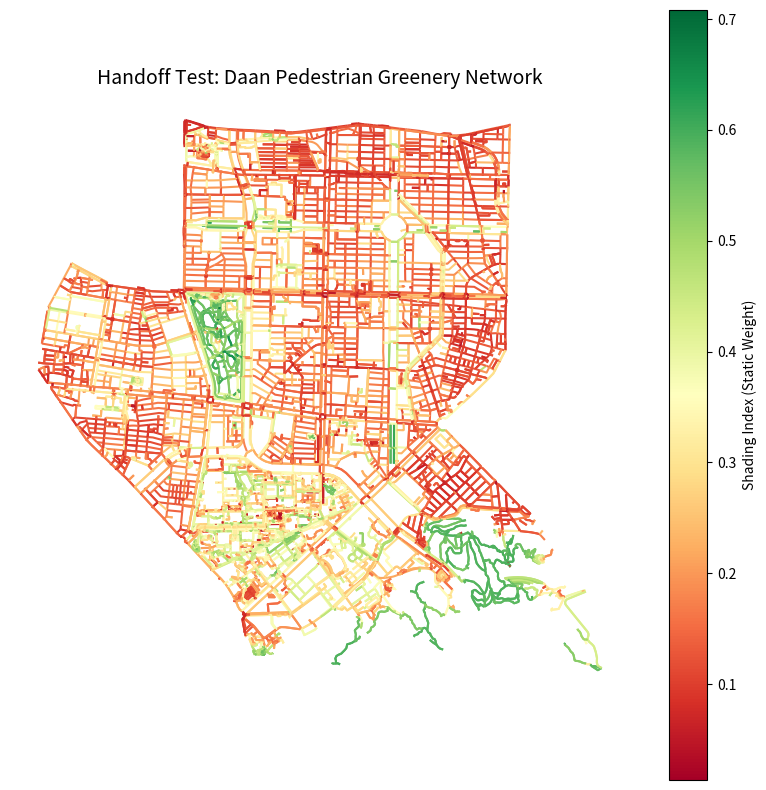

⏳ 正在模擬演算法同學載入 CSV 權重表...
✅ CSV 載入成功！關鍵欄位檢查: ['osmid', 'name', 'highway', 'length', 'shading_index', 'safety_score', 'tree_count']...
--------------------------------------------------
🎊 恭喜！資料包已通過模擬交接測試，確認具備高度可用性。


In [ ]:
# ==========================================
# [Task 4] Validation: Simulating Handoff
# ──────────────────────────────────────────────────────────────────
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. 定義隊友拿到的檔案路徑 (模擬從雲端讀取)
GEOJSON_PATH = os.path.join(OUTPUT_DIR, 'Daan_Shaded_Network(還原)_v1.geojson')
CSV_PATH = os.path.join(OUTPUT_DIR, 'Daan_Shaded_Network(還原)_v1.csv')

print("⏳ [1/3] 正在模擬隊友載入 GeoJSON 檔案...")
try:
    # 模擬視覺化同學載入地圖
    test_gdf = gpd.read_file(GEOJSON_PATH)
    print(f"✅ GeoJSON 載入成功！包含 {len(test_gdf)} 條完整路段幾何。")

    # 2. 數據健診 (Data Health Check)
    print("⏳ [2/3] 正在進行指標範圍檢查...")
    s_min, s_max = test_gdf['shading_index'].min(), test_gdf['shading_index'].max()
    print(f"📊 遮蔭指數範圍: {s_min:.2f} ~ {s_max:.2f} (預期應在 0~1 之間)")

    if 0 <= s_min <= 1 and 0 <= s_max <= 1:
        print("🟢 [PASS] 權重正規化邏輯正確。")
    else:
        print("🔴 [FAIL] 權重範圍異常，請檢查 Task 3.1。")

    # 3. 快速出圖測試 (不用 Folium，用最基礎的 matplotlib)
    print("⏳ [3/3] 正在執行幾何渲染測試...")
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    test_gdf.plot(column='shading_index', cmap='RdYlGn', legend=True,
                  ax=ax, legend_kwds={'label': "Shading Index (Static Weight)"})
    plt.title("Handoff Test: Daan Pedestrian Greenery Network", fontsize=14)
    plt.axis('off')
    plt.show()

    # 4. 模擬演算法同學讀取 CSV
    print("⏳ 正在模擬演算法同學載入 CSV 權重表...")
    test_df = pd.read_csv(CSV_PATH)
    print(f"✅ CSV 載入成功！關鍵欄位檢查: {test_df.columns.tolist()[:8]}...")

except Exception as e:
    print(f"❌ 模擬載入失敗！錯誤訊息: {e}")
    print("💡 建議檢查 Task 3.2 的檔案匯出邏輯。")

print("-" * 50)
print("🎊 恭喜！資料包已通過模擬交接測試，確認具備高度可用性。")

###測試：GPKG to GraphML

In [19]:
# ==========================================
# [Task 4] GPKG to GraphML Conversion (防呆修正版)
# ──────────────────────────────────────────────────────────────────
import geopandas as gpd
import osmnx as ox
import networkx as nx
import os

print("⏳ [1/3] 正在讀取 GPKG 中的節點 (Nodes) 與邊 (Edges) 圖層...")
gpkg_file = os.path.join(OUTPUT_DIR, 'Daan_Shaded_Network(還原)_v1.gpkg')
graphml_file = os.path.join(OUTPUT_DIR, 'Daan_Shaded_Network(還原)_v1.graphml')

gdf_nodes = gpd.read_file(gpkg_file, layer='nodes')
gdf_edges = gpd.read_file(gpkg_file, layer='edges')

print("⏳ [2/3] 正在進行拓樸索引設定與格式清理...")

# 確保 Nodes 有 x, y 欄位
if 'x' not in gdf_nodes.columns:
    gdf_nodes['x'] = gdf_nodes.geometry.x
if 'y' not in gdf_nodes.columns:
    gdf_nodes['y'] = gdf_nodes.geometry.y

# 1. 設定 Nodes Index
if 'osmid' in gdf_nodes.columns:
    gdf_nodes.set_index('osmid', inplace=True)

# 2. 嚴格檢查 u, v 並設定 Edges MultiIndex
if 'u' not in gdf_edges.columns or 'v' not in gdf_edges.columns:
    raise ValueError("❌ 在 GPKG 裡找不到 'u' 和 'v' 欄位！請確保您已重新執行修正版的 Task 3.3。")

if 'key' not in gdf_edges.columns:
    gdf_edges['key'] = 0

# 💡 強制設定 OSMnx 規定的 MultiIndex 名稱
gdf_edges.set_index(['u', 'v', 'key'], inplace=True)

# 3. 屬性清理 (保留 Shapely geometry 不動)
def sanitize_attributes(gdf):
    for col in gdf.columns:
        if col == 'geometry':
            continue
        else:
            gdf[col] = gdf[col].fillna("")
            if gdf[col].dtype == 'object' or gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
                gdf[col] = gdf[col].astype(str)
    return gdf

gdf_nodes = sanitize_attributes(gdf_nodes)
gdf_edges = sanitize_attributes(gdf_edges)

print("⏳ [3/3] 正在轉換為 NetworkX 物件並匯出 GraphML...")
G = ox.graph_from_gdfs(gdf_nodes, gdf_edges)
ox.save_graphml(G, graphml_file)

print("-" * 50)
print(f"✅ 轉換成功！已順利產出路徑分析專用的 GraphML 檔案。")
print(f"📦 GraphML 檔案位置: {os.path.basename(graphml_file)}")

⏳ [1/3] 正在讀取 GPKG 中的節點 (Nodes) 與邊 (Edges) 圖層...
⏳ [2/3] 正在進行拓樸索引設定與格式清理...
⏳ [3/3] 正在轉換為 NetworkX 物件並匯出 GraphML...
--------------------------------------------------
✅ 轉換成功！已順利產出路徑分析專用的 GraphML 檔案。
📦 GraphML 檔案位置: Daan_Shaded_Network(還原)_v1.graphml


⏳ 正在讀取 GraphML 檔案: Daan_Shaded_Network(還原)_v1.graphml...
--------------------------------------------------
✅ GraphML 讀取成功！
📍 節點數量 (Nodes): 9785
🛤️ 邊緣數量 (Edges): 25332

🔍 隨機抽查一條路段的屬性 (Edge Attributes):
  - osmid: 39519610
  - highway: residential
  - name: 垂葉榕道
  - length: 12.055231629073232
  - shading_index: 0.32319815361252535
  - safety_score: 0.7
  - tree_count: 0
--------------------------------------------------
🗺️ 正在繪製路網預覽圖 (紅點為 Nodes，灰線為 Edges)...


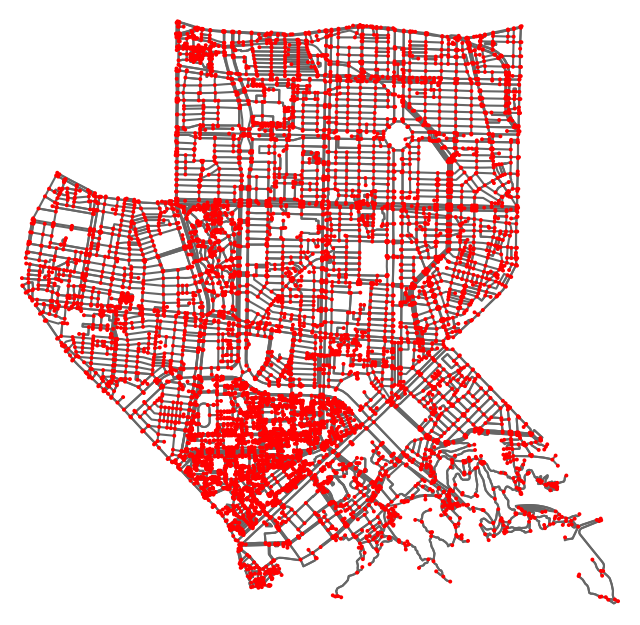

In [25]:
# ==========================================
# [Task 5] 驗證與視覺化 GraphML (確認轉檔結果)
# ──────────────────────────────────────────────────────────────────
import osmnx as ox
import os

graphml_file = os.path.join(OUTPUT_DIR, 'Daan_Shaded_Network(還原)_v1.graphml')

print(f"⏳ 正在讀取 GraphML 檔案: {os.path.basename(graphml_file)}...")

try:
    # 1. 讀取 GraphML 檔案
    G_loaded = ox.load_graphml(graphml_file)

    # 2. 印出基本網路拓樸資訊
    num_nodes = len(G_loaded.nodes)
    num_edges = len(G_loaded.edges)
    print("-" * 50)
    print("✅ GraphML 讀取成功！")
    print(f"📍 節點數量 (Nodes): {num_nodes}")
    print(f"🛤️ 邊緣數量 (Edges): {num_edges}")

    # 3. 隨機抽查一條 Edge 的屬性，確認你的心血 (權重) 都有順利交接
    # list(G_loaded.edges(data=True)) 會回傳 (u, v, data_dict)
    sample_edge = list(G_loaded.edges(data=True))[0]
    print("\n🔍 隨機抽查一條路段的屬性 (Edge Attributes):")
    for key, value in sample_edge[2].items():
        # 挑選關鍵的欄位印出來檢查就好，避免洗版
        if key in ['osmid', 'name', 'highway', 'length', 'shading_index', 'safety_score', 'tree_count']:
            print(f"  - {key}: {value}")
    print("-" * 50)

    # 4. 繪製簡單的路網圖來做最終視覺確認
    print("🗺️ 正在繪製路網預覽圖 (紅點為 Nodes，灰線為 Edges)...")
    fig, ax = ox.plot_graph(
        G_loaded,
        node_size=8,          # 節點大小
        node_color="red",     # 節點顏色
        edge_color="#666666", # 路段顏色
        edge_linewidth=1.5,   # 路段寬度
        bgcolor="white",      # 背景設為白色比較容易看
        show=True
    )

except Exception as e:
    print(f"❌ 讀取或繪製發生錯誤: {e}")